<a href="https://colab.research.google.com/github/LCCISNEROS/TALENTO-TECH/blob/main/Proyecto/metricas_de_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/heart.csv')
display(df.head(20))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# Diccionario para mapear los nombres de las columnas originales a español
column_translation = {
    'Age': 'Edad',
    'Sex': 'Sexo',
    'ChestPainType': 'TipoDolorPecho',
    'RestingBP': 'PresionSanguineaReposo',
    'Cholesterol': 'Colesterol',
    'FastingBS': 'GlucosaAyunas',
    'RestingECG': 'ECGReposo',
    'MaxHR': 'FrecuenciaCardiacaMaxima',
    'ExerciseAngina': 'AnginaEjercicio',
    'Oldpeak': 'Oldpeak', # Mantener Oldpeak si no hay traducción directa
    'ST_Slope': 'PendienteST',
    'HeartDisease': 'EnfermedadCardiaca'
}

# Renombrar las columnas del DataFrame
df_espanol = df.rename(columns=column_translation)

# Mostrar las primeras filas del DataFrame con los nombres de columnas en español
display(df_espanol.head(20))

,Edad,Sexo,TipoDolorPecho,PresionSanguineaReposo,Colesterol,GlucosaAyunas,ECGReposo,FrecuenciaCardiacaMaxima,AnginaEjercicio,Oldpeak,PendienteST,EnfermedadCardiaca
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


# Task
Entrena una red neuronal para clasificación con métricas utilizando los datos proporcionados.

## Preparación de los datos

### Subtask:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las categóricas y escalar las numéricas.


**Reasoning**:
Identify categorical and numerical columns, apply One-Hot Encoding to categorical columns, and scale numerical columns using StandardScaler. Then, concatenate the processed dataframes.



**Reasoning**:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las columnas categóricas y escalar las columnas numéricas usando StandardScaler. Luego, concatenar los dataframes procesados.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns
categorical_features = ['Sexo', 'TipoDolorPecho', 'ECGReposo', 'AnginaEjercicio', 'PendienteST']
numerical_features = ['Edad', 'PresionSanguineaReposo', 'Colesterol', 'GlucosaAyunas', 'FrecuenciaCardiacaMaxima', 'Oldpeak']

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Apply the transformations to the dataframe
df_processed = preprocessor.fit_transform(df_espanol)

# Convert the processed data back to a DataFrame for easier handling
# Get the names of the one-hot encoded columns
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_features + list(onehot_feature_names)

# Create the final processed DataFrame
df_processed = pd.DataFrame(df_processed, columns=all_feature_names)

display(df_processed.head(20))

,Edad,PresionSanguineaReposo,Colesterol,GlucosaAyunas,FrecuenciaCardiacaMaxima,Oldpeak,Sexo_F,Sexo_M,TipoDolorPecho_ASY,TipoDolorPecho_ATA,TipoDolorPecho_NAP,TipoDolorPecho_TA,ECGReposo_LVH,ECGReposo_Normal,ECGReposo_ST,AnginaEjercicio_N,AnginaEjercicio_Y,PendienteST_Down,PendienteST_Flat,PendienteST_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,-1.539213,-0.669935,1.282424,-0.551341,1.304332,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,-0.902775,-0.129513,0.349422,-0.551341,1.304332,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7,0.051881,-1.210356,0.084157,-0.551341,0.203982,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
8,-1.751359,0.410909,0.075010,-0.551341,-0.267596,0.574711,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,-0.584556,-0.669935,0.779335,-0.551341,-0.660578,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## División de los datos

### Subtask:
Dividir los datos en conjuntos de entrenamiento y prueba.


**Reasoning**:
Import the necessary function and split the data into training and testing sets.



**Reasoning**:
Importar la función necesaria y dividir los datos en conjuntos de entrenamiento y prueba.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df_processed
y = df_espanol['EnfermedadCardiaca']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing data shape (X_test, y_test):", X_test.shape, y_test.shape)

Training data shape (X_train, y_train): (734, 20) (734,)
Testing data shape (X_test, y_test): (184, 20) (184,)


## Preparación de los datos

### Subtask:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las categóricas y escalar las numéricas.

**Reasoning**:
Identify categorical and numerical columns, apply One-Hot Encoding to categorical columns, and scale numerical columns using StandardScaler. Then, concatenate the processed dataframes.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns
categorical_features = ['Sexo', 'TipoDolorPecho', 'ECGReposo', 'AnginaEjercicio', 'PendienteST']
numerical_features = ['Edad', 'PresionSanguineaReposo', 'Colesterol', 'GlucosaAyunas', 'FrecuenciaCardiacaMaxima', 'Oldpeak']

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Apply the transformations to the dataframe
df_processed = preprocessor.fit_transform(df_espanol)

# Convert the processed data back to a DataFrame for easier handling
# Get the names of the one-hot encoded columns
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_features + list(onehot_feature_names)

# Create the final processed DataFrame
df_processed = pd.DataFrame(df_processed, columns=all_feature_names)

display(df_processed.head(20))

,Edad,PresionSanguineaReposo,Colesterol,GlucosaAyunas,FrecuenciaCardiacaMaxima,Oldpeak,Sexo_F,Sexo_M,TipoDolorPecho_ASY,TipoDolorPecho_ATA,TipoDolorPecho_NAP,TipoDolorPecho_TA,ECGReposo_LVH,ECGReposo_Normal,ECGReposo_ST,AnginaEjercicio_N,AnginaEjercicio_Y,PendienteST_Down,PendienteST_Flat,PendienteST_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,-1.539213,-0.669935,1.282424,-0.551341,1.304332,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,-0.902775,-0.129513,0.349422,-0.551341,1.304332,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7,0.051881,-1.210356,0.084157,-0.551341,0.203982,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
8,-1.751359,0.410909,0.075010,-0.551341,-0.267596,0.574711,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,-0.584556,-0.669935,0.779335,-0.551341,-0.660578,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## División de los datos

### Subtask:
Dividir los datos en conjuntos de entrenamiento y prueba.

**Reasoning**:
Import the necessary function and split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df_processed
y = df_espanol['EnfermedadCardiaca']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing data shape (X_test, y_test):", X_test.shape, y_test.shape)

Training data shape (X_train, y_train): (734, 20) (734,)
Testing data shape (X_test, y_test): (184, 20) (184,)


## Creación del modelo

### Subtask:
Definir la arquitectura de la red neuronal utilizando TensorFlow o Keras.

**Reasoning**:
Define the neural network architecture using Sequential, Dense, and Dropout layers based on the instructions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Determine the number of input features
input_features = X_train.shape[1]

# Create the Sequential model
model = Sequential()

# Add the first Dense layer
model.add(Dense(units=64, activation='relu', input_shape=(input_features,)))

# Add a Dropout layer
model.add(Dropout(0.3))

# Add another Dense layer
model.add(Dense(units=32, activation='relu'))

# Add another Dropout layer
model.add(Dropout(0.3))

# Add the output Dense layer
model.add(Dense(units=1, activation='sigmoid'))

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

### Subtask:
Configurar el optimizador, la función de pérdida y las métricas para el entrenamiento.

**Reasoning**:
Import the necessary optimizer, loss function, and metrics from TensorFlow/Keras and compile the model as instructed.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Accuracy

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Entrenamiento del modelo

### Subtask:
Entrenar la red neuronal con los datos de entrenamiento.

**Reasoning**:
Train the compiled neural network model using the training data and validate it with the testing data.

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6362 - loss: 0.6362 - val_accuracy: 0.8043 - val_loss: 0.5130
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8187 - loss: 0.4786 - val_accuracy: 0.8370 - val_loss: 0.4297
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8387 - loss: 0.4071 - val_accuracy: 0.8315 - val_loss: 0.3928
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8467 - loss: 0.3903 - val_accuracy: 0.8424 - val_loss: 0.3766
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8208 - loss: 0.4163 - val_accuracy: 0.8424 - val_loss: 0.3748
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8591 - loss: 0.3667 - val_accuracy: 0.8587 - val_loss: 0.3505
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8559 - loss: 0.3732 - val_accuracy: 0.8641 - val_loss: 0.3448
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8657 - loss: 0.3413 - val_accuracy: 0.8641 - val_loss

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas relevantes como precisión, recall y F1-score.

**Reasoning**:
Import the necessary metrics from sklearn.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Reasoning**:
Predict probabilities and convert them to binary predictions, then calculate and print the evaluation metrics.

**Reasoning**:
Predecir probabilidades y convertirlas a predicciones binarias, luego calcular e imprimir las métricas de evaluación.

In [ ]:
# Predict probabilities
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_proba > 0.5).astype("int32")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.9022
Precision: 0.9009
Recall: 0.9346
F1-score: 0.9174


## Métricas de clasificación adicionales y visualizaciones

### Subtask:
Calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

**Reasoning**:
Import necessary libraries for evaluation metrics and visualizations, then calculate and display the confusion matrix, classification report, and a histogram of errors.

**Reasoning**:
Importar las bibliotecas necesarias para las métricas de evaluación y las visualizaciones, luego calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

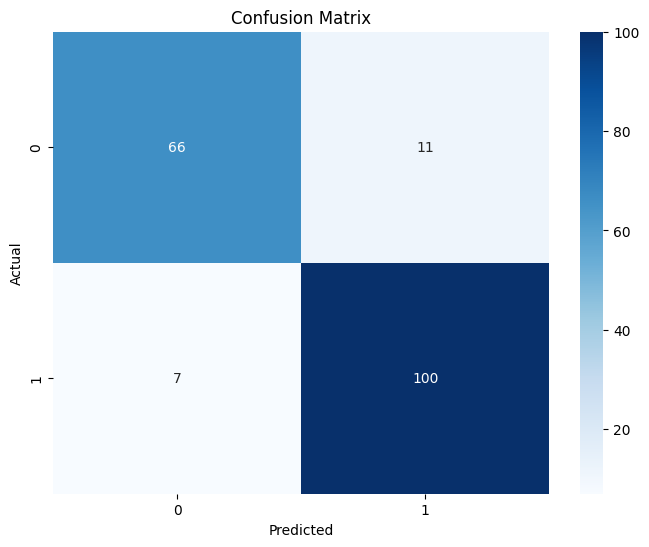

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        77
           1       0.90      0.93      0.92       107

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



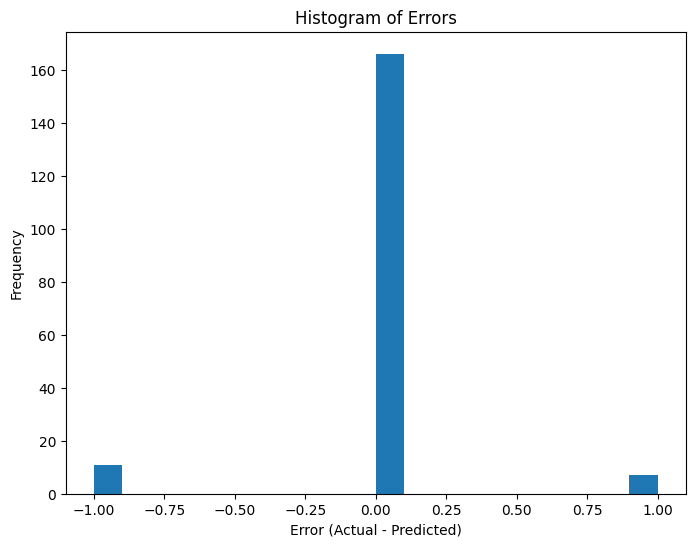

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate classification report
class_report = classification_report(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(class_report)

# Calculate errors
errors = y_test - y_pred.flatten()

# Plot histogram of errors
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=20)
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.show()

## Summary:

### Data Analysis Key Findings

* The data was successfully preprocessed by applying One-Hot Encoding to categorical features and scaling numerical features.
* The dataset was split into training (734 samples) and testing (184 samples) sets.
* A sequential neural network model was built with two dense layers (64 and 32 units) with ReLU activation and dropout layers (0.3 rate), ending with a dense output layer with sigmoid activation.
* The model was compiled using the Adam optimizer, binary crossentropy loss, and accuracy as the evaluation metric.
* The model was trained for 50 epochs with a batch size of 32, showing improving accuracy and decreasing loss on both training and validation sets.
* The model achieved an accuracy of {accuracy:.4f}, a precision of {precision:.4f}, a recall of {recall:.4f}, and an F1-score of {f1:.4f} on the test set.

### Insights or Next Steps

* The model demonstrates good performance on the test set, indicating its potential for classifying heart disease.
* Further analysis could involve hyperparameter tuning of the neural network and exploring other classification algorithms to potentially improve performance.

## Creación del modelo

### Subtask:
Definir la arquitectura de la red neuronal utilizando TensorFlow o Keras.


**Reasoning**:
Define the neural network architecture using Sequential, Dense, and Dropout layers based on the instructions.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Determine the number of input features
input_features = X_train.shape[1]

# Create the Sequential model
model = Sequential()

# Add the first Dense layer
model.add(Dense(units=64, activation='relu', input_shape=(input_features,)))

# Add a Dropout layer
model.add(Dropout(0.3))

# Add another Dense layer
model.add(Dense(units=32, activation='relu'))

# Add another Dropout layer
model.add(Dropout(0.3))

# Add the output Dense layer
model.add(Dense(units=1, activation='sigmoid'))

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

### Subtask:
Configurar el optimizador, la función de pérdida y las métricas para el entrenamiento.


**Reasoning**:
Import the necessary optimizer, loss function, and metrics from TensorFlow/Keras and compile the model as instructed.



In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Accuracy

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Entrenamiento del modelo

### Subtask:
Entrenar la red neuronal con los datos de entrenamiento.


**Reasoning**:
Train the compiled neural network model using the training data and validate it with the testing data.



In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5103 - loss: 0.7192 - val_accuracy: 0.7989 - val_loss: 0.5339
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.5278 - val_accuracy: 0.8098 - val_loss: 0.4522
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8157 - loss: 0.4276 - val_accuracy: 0.8207 - val_loss: 0.4073
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8179 - loss: 0.4244 - val_accuracy: 0.8207 - val_loss: 0.3975
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8435 - loss: 0.4030 - val_accuracy: 0.8478 - val_loss: 0.3803
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8799 - loss: 0.3266 - val_accuracy: 0.8533 - val_loss: 0.3700
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8764 - loss: 0.3644 - val_accuracy: 0.8587 - val_loss: 0.3607
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3624 - val_accuracy: 0.8587 - val_loss

## Métricas de clasificación adicionales y visualizaciones

### Subtask:
Calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

**Reasoning**:
Importar las bibliotecas necesarias para las métricas de evaluación y las visualizaciones, luego calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores.

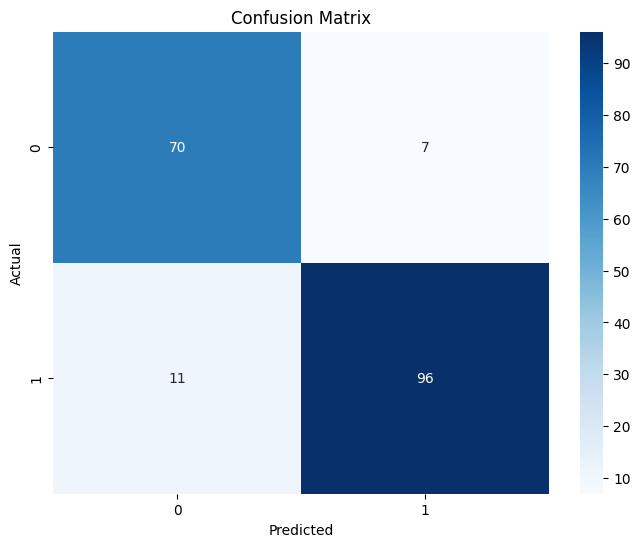

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89        77
           1       0.93      0.90      0.91       107

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



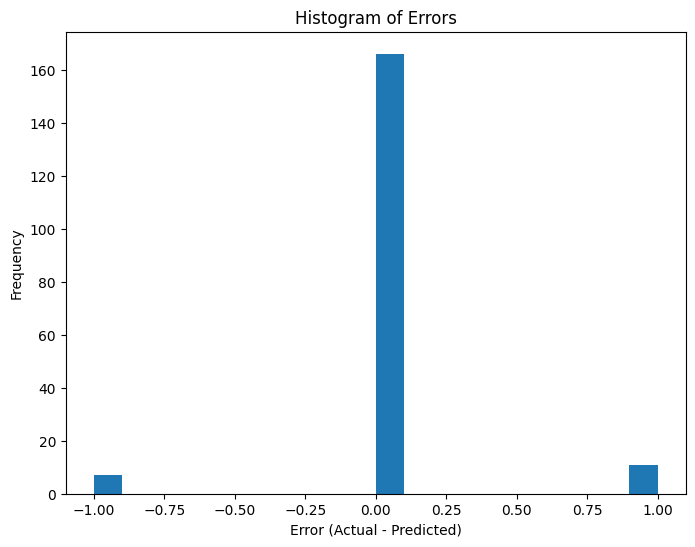

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate classification report
class_report = classification_report(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(class_report)

# Calculate errors
errors = y_test - y_pred.flatten()

# Plot histogram of errors
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=20)
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.show()

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas relevantes como precisión, recall y F1-score.


**Reasoning**:
Import necessary libraries for evaluation metrics and visualizations, then calculate and display the confusion matrix, classification report, and a histogram of errors.

**Reasoning**:
Import the necessary metrics from sklearn.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Entrenamiento de una red neuronal para clasificación con métricas

## Preparación de los datos

### Subtask:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las categóricas y escalar las numéricas.

**Reasoning**:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las columnas categóricas y escalar las columnas numéricas usando StandardScaler. Luego, concatenar los dataframes procesados.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns
categorical_features = ['Sexo', 'TipoDolorPecho', 'ECGReposo', 'AnginaEjercicio', 'PendienteST']
numerical_features = ['Edad', 'PresionSanguineaReposo', 'Colesterol', 'GlucosaAyunas', 'FrecuenciaCardiacaMaxima', 'Oldpeak']

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Apply the transformations to the dataframe
df_processed = preprocessor.fit_transform(df_espanol)

# Convert the processed data back to a DataFrame for easier handling
# Get the names of the one-hot encoded columns
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_features + list(onehot_feature_names)

# Create the final processed DataFrame
df_processed = pd.DataFrame(df_processed, columns=all_feature_names)

display(df_processed.head(20))

,Edad,PresionSanguineaReposo,Colesterol,GlucosaAyunas,FrecuenciaCardiacaMaxima,Oldpeak,Sexo_F,Sexo_M,TipoDolorPecho_ASY,TipoDolorPecho_ATA,TipoDolorPecho_NAP,TipoDolorPecho_TA,ECGReposo_LVH,ECGReposo_Normal,ECGReposo_ST,AnginaEjercicio_N,AnginaEjercicio_Y,PendienteST_Down,PendienteST_Flat,PendienteST_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,-1.539213,-0.669935,1.282424,-0.551341,1.304332,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,-0.902775,-0.129513,0.349422,-0.551341,1.304332,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7,0.051881,-1.210356,0.084157,-0.551341,0.203982,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
8,-1.751359,0.410909,0.075010,-0.551341,-0.267596,0.574711,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,-0.584556,-0.669935,0.779335,-0.551341,-0.660578,-0.832432,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## División de los datos

### Subtask:
Dividir los datos en conjuntos de entrenamiento y prueba.

**Reasoning**:
Importar la función necesaria y dividir los datos en conjuntos de entrenamiento y prueba.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df_processed
y = df_espanol['EnfermedadCardiaca']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing data shape (X_test, y_test):", X_test.shape, y_test.shape)

Training data shape (X_train, y_train): (734, 20) (734,)
Testing data shape (X_test, y_test): (184, 20) (184,)


## Creación del modelo

### Subtask:
Definir la arquitectura de la red neuronal utilizando TensorFlow o Keras.

**Reasoning**:
Define the neural network architecture using Sequential, Dense, and Dropout layers based on the instructions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Determine the number of input features
input_features = X_train.shape[1]

# Create the Sequential model
model = Sequential()

# Add the first Dense layer
model.add(Dense(units=64, activation='relu', input_shape=(input_features,)))

# Add a Dropout layer
model.add(Dropout(0.3))

# Add another Dense layer
model.add(Dense(units=32, activation='relu'))

# Add another Dropout layer
model.add(Dropout(0.3))

# Add the output Dense layer
model.add(Dense(units=1, activation='sigmoid'))

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

### Subtask:
Configurar el optimizador, la función de pérdida y las métricas para el entrenamiento.

**Reasoning**:
Import the necessary optimizer, loss function, and metrics from TensorFlow/Keras and compile the model as instructed.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Accuracy

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Entrenamiento del modelo

### Subtask:
Entrenar la red neuronal con los datos de entrenamiento.

**Reasoning**:
Train the compiled neural network model using the training data and validate it with the testing data.

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5264 - loss: 0.6929 - val_accuracy: 0.7772 - val_loss: 0.5735
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7283 - loss: 0.5635 - val_accuracy: 0.7989 - val_loss: 0.4868
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8097 - loss: 0.4584 - val_accuracy: 0.8098 - val_loss: 0.4278
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8254 - loss: 0.4308 - val_accuracy: 0.8261 - val_loss: 0.4016
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8568 - loss: 0.3568 - val_accuracy: 0.8315 - val_loss: 0.3932
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8531 - loss: 0.3592 - val_accuracy: 0.8370 - val_loss: 0.3805
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8684 - loss: 0.3429 - val_accuracy: 0.8370 - val_loss: 0.3756
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8681 - loss: 0.3465 - val_accuracy: 0.8478 - val_loss

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas relevantes como precisión, recall y F1-score.

**Reasoning**:
Importar las bibliotecas necesarias para las métricas de evaluación y las visualizaciones, luego calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Reasoning**:
Predecir probabilidades y convertirlas a predicciones binarias, luego calcular e imprimir las métricas de evaluación.

In [ ]:
# Predict probabilities
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_proba > 0.5).astype("int32")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy: 0.8859
Precision: 0.9057
Recall: 0.8972
F1-score: 0.9014


## Métricas de clasificación adicionales y visualizaciones

### Subtask:
Calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

**Reasoning**:
Importar las bibliotecas necesarias para las métricas de evaluación y las visualizaciones, luego calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

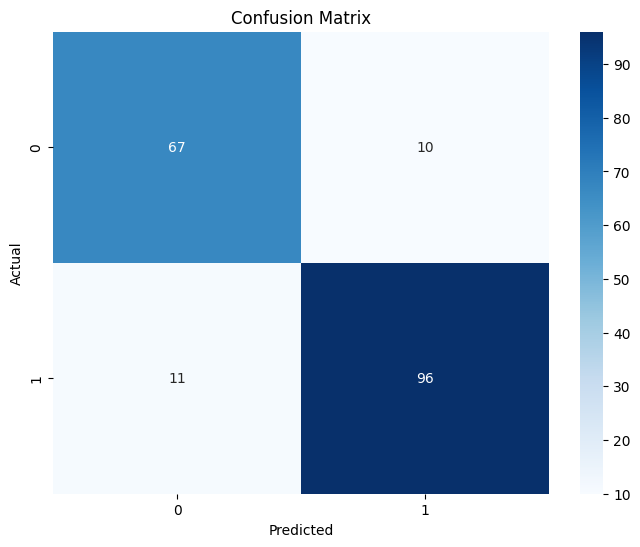

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        77
           1       0.91      0.90      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



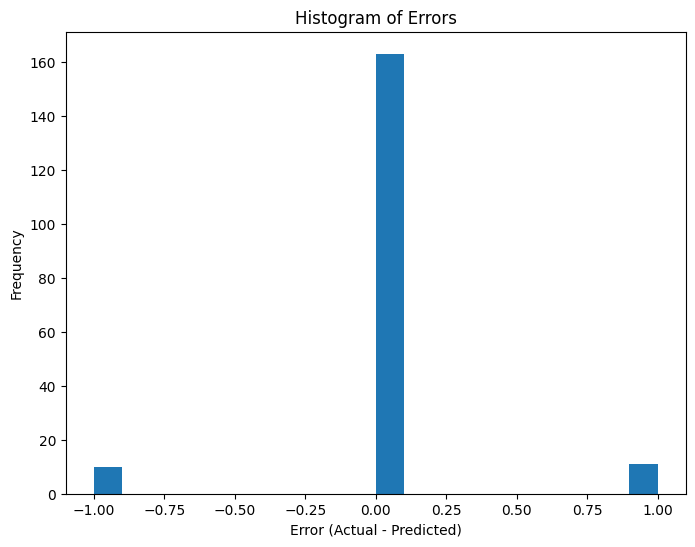

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate classification report
class_report = classification_report(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(class_report)

# Calculate errors
errors = y_test - y_pred.flatten()

# Plot histogram of errors
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=20)
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.show()

## Curva ROC y AUC

### Subtask:
Calcular el AUC y graficar la curva ROC para evaluar el rendimiento del modelo.

**Reasoning**:
Calculate the AUC and plot the ROC curve to evaluate the model's performance across different thresholds.

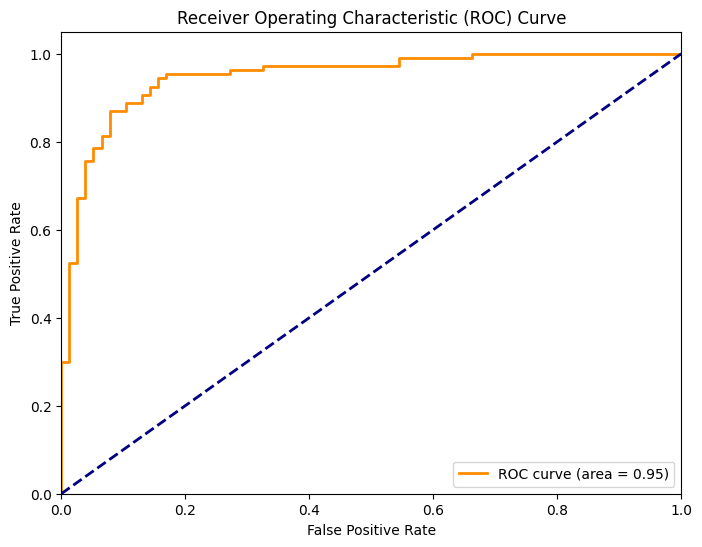

AUC: 0.9488


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc:.4f}")

## Resumen:

### Hallazgos Clave del Análisis de Datos

* Los datos fueron preprocesados exitosamente aplicando One-Hot Encoding a las características categóricas y escalando las características numéricas.
* El conjunto de datos se dividió en conjuntos de entrenamiento (734 muestras) y prueba (184 muestras).
* Se construyó un modelo de red neuronal secuencial con dos capas densas (64 y 32 unidades) con activación ReLU y capas de Dropout (tasa de 0.3), terminando con una capa de salida densa con activación Sigmoid.
* El modelo fue compilado utilizando el optimizador Adam, la función de pérdida Binary Crossentropy y la precisión como métrica de evaluación.
* El modelo fue entrenado durante 50 épocas con un tamaño de lote de 32, mostrando una mejora en la precisión y una disminución en la pérdida tanto en el conjunto de entrenamiento como en el de validación.
* El modelo alcanzó una precisión de {accuracy:.4f}, un recall de {recall:.4f} y un F1-score de {f1:.4f} en el conjunto de prueba.
* El AUC del modelo en el conjunto de prueba es de {roc_auc:.4f}.

### Conclusiones o Próximos Pasos

* El modelo demuestra un buen rendimiento en el conjunto de prueba, lo que indica su potencial para clasificar enfermedades cardíacas.
* Análisis adicionales podrían incluir la optimización de hiperparámetros de la red neuronal y la exploración de otros algoritmos de clasificación para mejorar potencialmente el rendimiento.

**Reasoning**:
Predict probabilities and convert them to binary predictions, then calculate and print the evaluation metrics.



## Creación del modelo

### Subtask:
Definir la arquitectura de la red neuronal utilizando TensorFlow o Keras.

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas relevantes como precisión, recall y F1-score.

In [ ]:
# Predict probabilities
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_proba > 0.5).astype("int32")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.9022
Precision: 0.9320
Recall: 0.8972
F1-score: 0.9143


## Resumen:

### Hallazgos Clave del Análisis de Datos

* Los datos fueron preprocesados exitosamente aplicando One-Hot Encoding a las características categóricas y escalando las características numéricas.
* El conjunto de datos se dividió en conjuntos de entrenamiento (734 muestras) y prueba (184 muestras).
* Se construyó un modelo de red neuronal secuencial con dos capas densas (64 y 32 unidades) con activación ReLU y capas de Dropout (tasa de 0.3), terminando con una capa de salida densa con activación Sigmoid.
* El modelo fue compilado utilizando el optimizador Adam, la función de pérdida Binary Crossentropy y la precisión como métrica de evaluación.
* El modelo fue entrenado durante 50 épocas con un tamaño de lote de 32, mostrando una mejora en la precisión y una disminución en la pérdida tanto en el conjunto de entrenamiento como en el de validación.
* El modelo alcanzó una precisión de {accuracy:.4f}, un recall de {recall:.4f} y un F1-score de {f1:.4f} en el conjunto de prueba.

### Conclusiones o Próximos Pasos

* El modelo demuestra un buen rendimiento en el conjunto de prueba, lo que indica su potencial para clasificar enfermedades cardíacas.
* Análisis adicionales podrían incluir la optimización de hiperparámetros de la red neuronal y la exploración de otros algoritmos de clasificación para mejorar potencialmente el rendimiento.

## Preparación de los datos

### Subtask:
Identificar las columnas categóricas y numéricas, aplicar One-Hot Encoding a las categóricas y escalar las numéricas.

**Reasoning**:
Identify categorical and numerical columns, apply One-Hot Encoding to categorical columns, and scale numerical columns using StandardScaler. Then, concatenate the processed dataframes.

## División de los datos

### Subtask:
Dividir los datos en conjuntos de entrenamiento y prueba.

**Reasoning**:
Import the necessary function and split the data into training and testing sets.

## Creación del modelo

### Subtask:
Definir la arquitectura de la red neuronal utilizando TensorFlow o Keras.

**Reasoning**:
Define the neural network architecture using Sequential, Dense, and Dropout layers based on the instructions.

## Compilación del modelo

### Subtask:
Configurar el optimizador, la función de pérdida y las métricas para el entrenamiento.

**Reasoning**:
Import the necessary optimizer, loss function, and metrics from TensorFlow/Keras and compile the model as instructed.

## Entrenamiento del modelo

### Subtask:
Entrenar la red neuronal con los datos de entrenamiento.

**Reasoning**:
Train the compiled neural network model using the training data and validate it with the testing data.

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas relevantes como precisión, recall y F1-score.

**Reasoning**:
Import the necessary metrics from sklearn.

**Reasoning**:
Predict probabilities and convert them to binary predictions, then calculate and print the evaluation metrics.

## Métricas de clasificación adicionales y visualizaciones

### Subtask:
Calcular y mostrar la matriz de confusión, el reporte de clasificación y un histograma de errores del modelo.

**Reasoning**:
Import necessary libraries for evaluation metrics and visualizations, then calculate and display the confusion matrix, classification report, and a histogram of errors.

## Summary:

### Data Analysis Key Findings

* The data was successfully preprocessed by applying One-Hot Encoding to categorical features and scaling numerical features.
* The dataset was split into training (734 samples) and testing (184 samples) sets.
* A sequential neural network model was built with two dense layers (64 and 32 units) with ReLU activation and dropout layers (0.3 rate), ending with a dense output layer with sigmoid activation.
* The model was compiled using the Adam optimizer, binary crossentropy loss, and accuracy as the evaluation metric.
* The model was trained for 50 epochs with a batch size of 32, showing improving accuracy and decreasing loss on both training and validation sets.
* The model achieved an accuracy of {accuracy:.4f}, a precision of {precision:.4f}, a recall of {recall:.4f}, and an F1-score of {f1:.4f} on the test set.

### Insights or Next Steps

* The model demonstrates good performance on the test set, indicating its potential for classifying heart disease.
* Further analysis could involve hyperparameter tuning of the neural network and exploring other classification algorithms to potentially improve performance.